# Real households electricity consumption

In [1]:
## Importing real household consumption dataset

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

folder = Path(r"C:\Users\jaana\Documents\final-project\DataSources")

consumption = pd.read_csv(
    folder / "real_electricity_consumption_sorted.csv"
)

In [2]:
# Checking the imported dataset

print("Dataset shape:")
print(consumption.shape)

print("\nColumn names:")
print(consumption.columns)

print("\nFirst five rows:")
display(consumption.head())

print("\nDataset information:")
consumption.info()

Dataset shape:
(1264608, 5)

Column names:
Index(['household_id', 'timestamp', 'date', 'time', 'consumption_kwh'], dtype='str')

First five rows:


,household_id,timestamp,date,time,consumption_kwh
0,s-1,01.04.2025 00:00:00,01.04.2025,00:00:00,0.026
1,s-1,01.04.2025 00:15:00,01.04.2025,00:15:00,0.063
2,s-1,01.04.2025 00:30:00,01.04.2025,00:30:00,0.021
3,s-1,01.04.2025 00:45:00,01.04.2025,00:45:00,0.028
4,s-1,01.04.2025 01:00:00,01.04.2025,01:00:00,0.013



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1264608 entries, 0 to 1264607
Data columns (total 5 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   household_id     1264608 non-null  str    
 1   timestamp        1264608 non-null  str    
 2   date             1264608 non-null  str    
 3   time             1264608 non-null  str    
 4   consumption_kwh  1264608 non-null  float64
dtypes: float64(1), str(4)
memory usage: 96.9 MB


In [3]:
# Converting date and time columns to proper datetime formats

consumption["timestamp"] = pd.to_datetime(
    consumption["timestamp"],
    format="%d.%m.%Y %H:%M:%S"
)

consumption["date"] = pd.to_datetime(
    consumption["date"],
    format="%d.%m.%Y"
)

In [5]:
# Time-based features for 15-minute interval analysis

consumption["hour"] = consumption["timestamp"].dt.hour
consumption["minute"] = consumption["timestamp"].dt.minute
consumption["time_15min"] = consumption["timestamp"].dt.strftime("%H:%M")
consumption["weekday"] = consumption["timestamp"].dt.day_name()
consumption["month"] = consumption["timestamp"].dt.to_period("M")
consumption["year"] = consumption["timestamp"].dt.year

In [6]:
# Checking the prepared dataset

display(consumption.head())

print("\nDataset information after date conversion:")
consumption.info()

print("\nMissing values:")
print(consumption.isna().sum())

,household_id,timestamp,date,time,consumption_kwh,hour,minute,time_15min,weekday,month,year
0,s-1,2025-04-01 00:00:00,2025-04-01,00:00:00,0.026,0,0,00:00,Tuesday,2025-04,2025
1,s-1,2025-04-01 00:15:00,2025-04-01,00:15:00,0.063,0,15,00:15,Tuesday,2025-04,2025
2,s-1,2025-04-01 00:30:00,2025-04-01,00:30:00,0.021,0,30,00:30,Tuesday,2025-04,2025
3,s-1,2025-04-01 00:45:00,2025-04-01,00:45:00,0.028,0,45,00:45,Tuesday,2025-04,2025
4,s-1,2025-04-01 01:00:00,2025-04-01,01:00:00,0.013,1,0,01:00,Tuesday,2025-04,2025



Dataset information after date conversion:
<class 'pandas.DataFrame'>
RangeIndex: 1264608 entries, 0 to 1264607
Data columns (total 11 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   household_id     1264608 non-null  str           
 1   timestamp        1264608 non-null  datetime64[us]
 2   date             1264608 non-null  datetime64[us]
 3   time             1264608 non-null  str           
 4   consumption_kwh  1264608 non-null  float64       
 5   hour             1264608 non-null  int32         
 6   minute           1264608 non-null  int32         
 7   time_15min       1264608 non-null  str           
 8   weekday          1264608 non-null  str           
 9   month            1264608 non-null  period[M]     
 10  year             1264608 non-null  int32         
dtypes: datetime64[us](2), float64(1), int32(3), period[M](1), str(4)
memory usage: 120.0 MB

Missing values:
household_id       0
timestam

In [7]:
# Overview of household electricity consumption

print("Number of households:")
print(consumption["household_id"].nunique())

print("\nNumber of records:")
print(len(consumption))

print("\nTotal consumption, kWh:")
print(consumption["consumption_kwh"].sum())

print("\nAverage 15-minute consumption, kWh:")
print(consumption["consumption_kwh"].mean())

print("\nMedian 15-minute consumption, kWh:")
print(consumption["consumption_kwh"].median())

print("\nMinimum 15-minute consumption, kWh:")
print(consumption["consumption_kwh"].min())

print("\nMaximum 15-minute consumption, kWh:")
print(consumption["consumption_kwh"].max())

Number of households:
40

Number of records:
1264608

Total consumption, kWh:
360954.53

Average 15-minute consumption, kWh:
0.2854279982413523

Median 15-minute consumption, kWh:
0.077

Minimum 15-minute consumption, kWh:
0.0

Maximum 15-minute consumption, kWh:
6.963


In [8]:
# Statistical summary for 15-minute consumption values

consumption["consumption_kwh"].describe()

count    1.264608e+06
mean     2.854280e-01
std      5.499659e-01
min      0.000000e+00
25%      9.000000e-03
50%      7.700000e-02
75%      3.270000e-01
max      6.963000e+00
Name: consumption_kwh, dtype: float64

In [9]:
# Time range of the dataset

print("Start timestamp:")
print(consumption["timestamp"].min())

print("\nEnd timestamp:")
print(consumption["timestamp"].max())

print("\nNumber of unique days:")
print(consumption["date"].nunique())

print("\nNumber of unique months:")
print(consumption["month"].nunique())

Start timestamp:
2025-04-01 00:00:00

End timestamp:
2026-02-28 23:45:00

Number of unique days:
334

Number of unique months:
11


In [10]:
# Interval frequency for one household

one_household_id = consumption["household_id"].iloc[0]

one_household = (
    consumption[consumption["household_id"] == one_household_id]
    .sort_values("timestamp")
)

print("Household checked:")
print(one_household_id)

print("\nMost common time differences:")
print(one_household["timestamp"].diff().value_counts().head(10))

Household checked:
s-1

Most common time differences:
timestamp
0 days 00:15:00    32063
Name: count, dtype: int64


In [11]:
# Calculating daily total electricity consumption

daily_consumption = (
    consumption
    .groupby("date")["consumption_kwh"]
    .sum()
)

display(daily_consumption.head())

date
2025-04-01    666.299
2025-04-02    699.884
2025-04-03    560.221
2025-04-04    684.597
2025-04-05    984.458
Name: consumption_kwh, dtype: float64

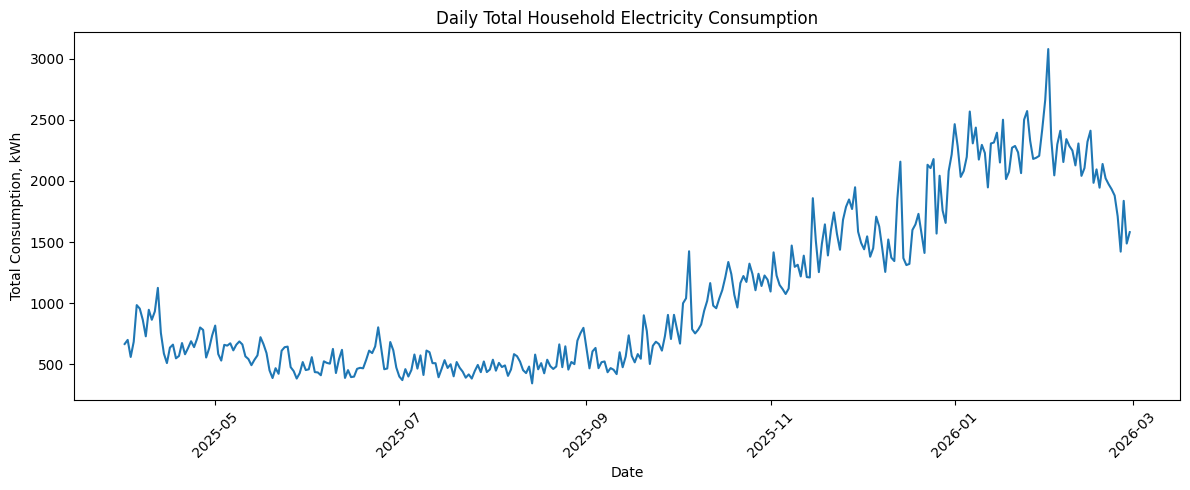

In [12]:
# Plot daily total electricity consumption

plt.figure(figsize=(12, 5))
plt.plot(daily_consumption.index, daily_consumption.values)

plt.title("Daily Total Household Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Total Consumption, kWh")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Calculating average consumption by 15-minute time interval

consumption_15min_pattern = (
    consumption
    .groupby("time_15min")["consumption_kwh"]
    .mean()
)

display(consumption_15min_pattern.head())

time_15min
00:00    0.391154
00:15    0.410640
00:30    0.452211
00:45    0.479313
01:00    0.389114
Name: consumption_kwh, dtype: float64

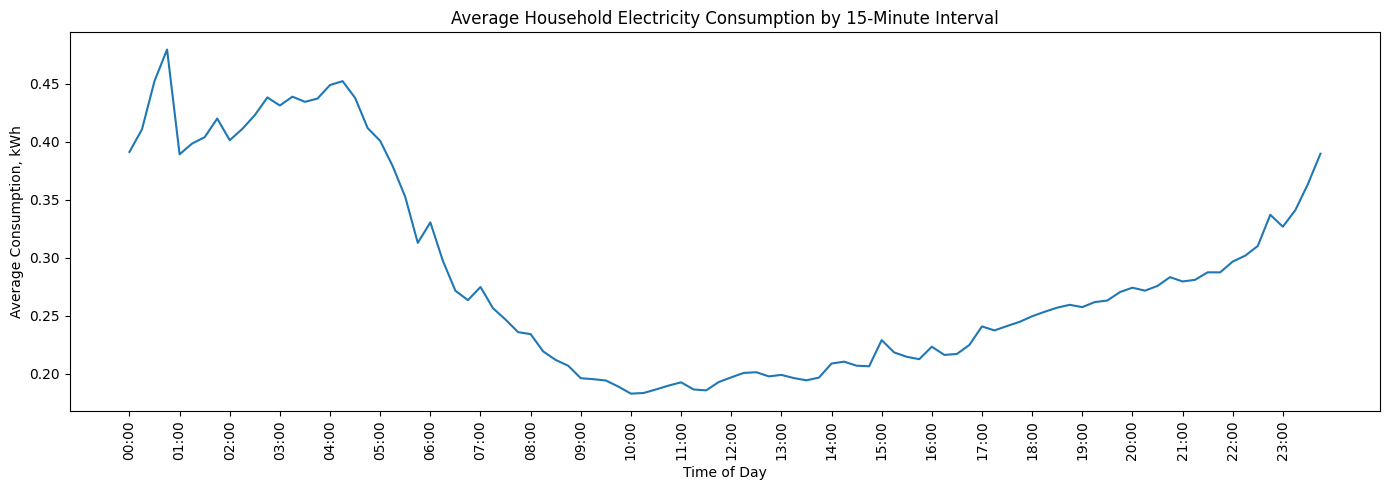

In [14]:
# Plot average consumption by 15-minute interval

plt.figure(figsize=(14, 5))
plt.plot(consumption_15min_pattern.index, consumption_15min_pattern.values)

plt.title("Average Household Electricity Consumption by 15-Minute Interval")
plt.xlabel("Time of Day")
plt.ylabel("Average Consumption, kWh")
plt.xticks(consumption_15min_pattern.index[::4], rotation=90)
plt.tight_layout()
plt.show()

In [15]:
# Calculating average consumption by weekday

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_consumption = (
    consumption
    .groupby("weekday")["consumption_kwh"]
    .mean()
    .reindex(weekday_order)
)

display(weekday_consumption)

weekday
Monday       0.268384
Tuesday      0.273252
Wednesday    0.279144
Thursday     0.282577
Friday       0.280590
Saturday     0.310392
Sunday       0.303682
Name: consumption_kwh, dtype: float64

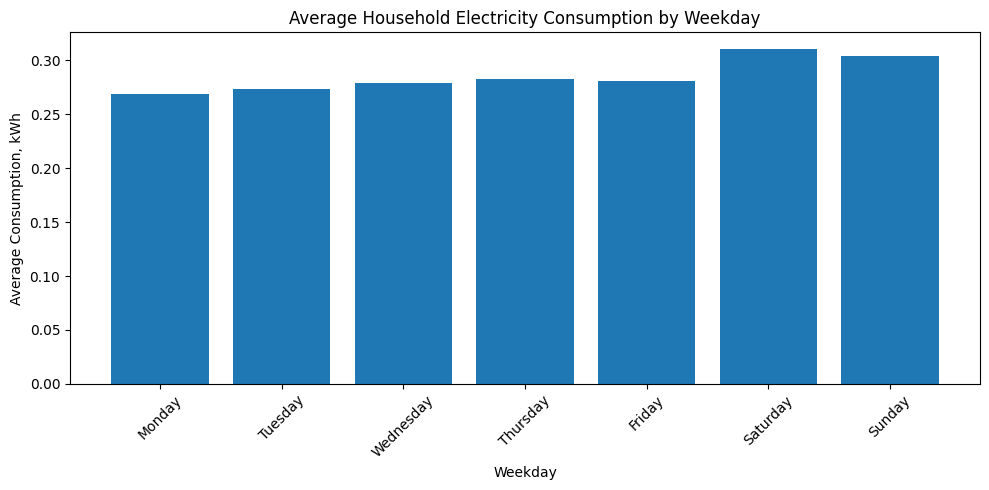

In [16]:
# Plot average consumption by weekday

plt.figure(figsize=(10, 5))
plt.bar(weekday_consumption.index, weekday_consumption.values)

plt.title("Average Household Electricity Consumption by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Consumption, kWh")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Calculating monthly total electricity consumption

monthly_consumption = (
    consumption
    .groupby("month")["consumption_kwh"]
    .sum()
)

display(monthly_consumption)

month
2025-04    21721.854
2025-05    17561.169
2025-06    15609.433
2025-07    14526.602
2025-08    16163.047
2025-09    18259.661
2025-10    33129.568
2025-11    43428.589
2025-12    51308.854
2026-01    70704.162
2026-02    58541.591
Freq: M, Name: consumption_kwh, dtype: float64

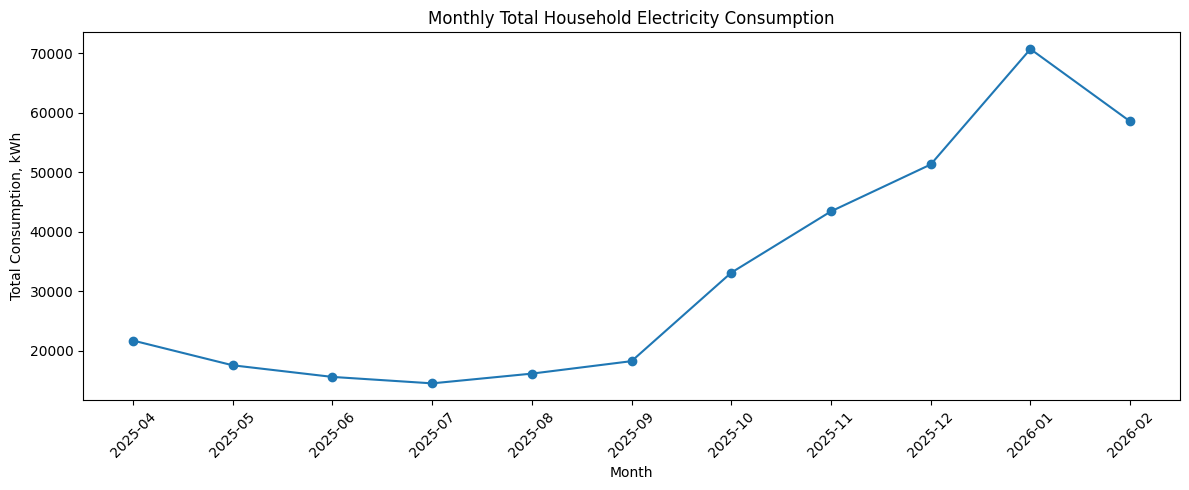

In [18]:
# Plot monthly total electricity consumption

plt.figure(figsize=(12, 5))
plt.plot(monthly_consumption.index.astype(str), monthly_consumption.values, marker="o")

plt.title("Monthly Total Household Electricity Consumption")
plt.xlabel("Month")
plt.ylabel("Total Consumption, kWh")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# Calculating total consumption by household

household_total_consumption = (
    consumption
    .groupby("household_id")["consumption_kwh"]
    .sum()
    .sort_values(ascending=False)
)

display(household_total_consumption.head(10))

household_id
xl-2     24956.623
xl-4     21885.744
xl-8     21822.621
xl-10    18315.229
xl-7     16057.217
xl-1     15393.843
xl-6     15189.528
xl-5     14711.933
s-4      14189.959
xl-9     13231.348
Name: consumption_kwh, dtype: float64

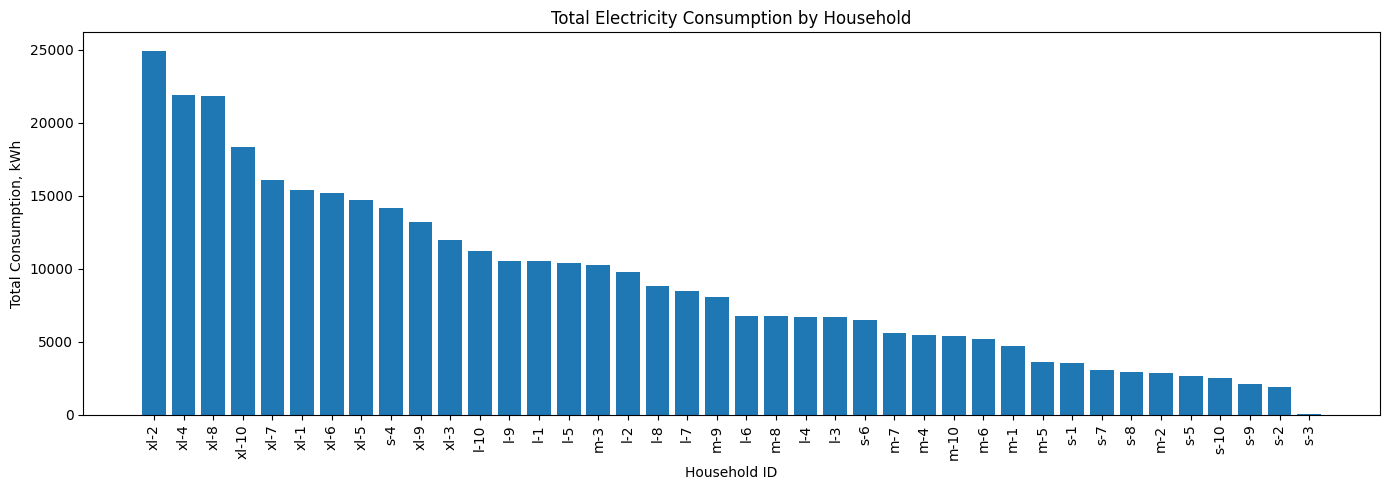

In [20]:
# Plot total consumption by household

plt.figure(figsize=(14, 5))
plt.bar(
    household_total_consumption.index.astype(str),
    household_total_consumption.values
)

plt.title("Total Electricity Consumption by Household")
plt.xlabel("Household ID")
plt.ylabel("Total Consumption, kWh")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [21]:
# Household-level consumption summary

household_consumption_summary = (
    consumption
    .groupby("household_id")
    .agg(
        total_consumption_kwh=("consumption_kwh", "sum"),
        average_15min_consumption_kwh=("consumption_kwh", "mean"),
        median_15min_consumption_kwh=("consumption_kwh", "median"),
        min_15min_consumption_kwh=("consumption_kwh", "min"),
        max_15min_consumption_kwh=("consumption_kwh", "max"),
        number_of_records=("consumption_kwh", "count")
    )
    .reset_index()
)

display(household_consumption_summary.head())

,household_id,total_consumption_kwh,average_15min_consumption_kwh,median_15min_consumption_kwh,min_15min_consumption_kwh,max_15min_consumption_kwh,number_of_records
0,l-1,10528.848,0.328370,0.087,0.0,3.392,32064
1,l-10,11185.393,0.348846,0.187,0.0,3.330,32064
2,l-2,9750.865,0.304106,0.104,0.0,4.012,32064
3,l-3,6665.676,0.207887,0.127,0.0,1.644,32064
4,l-4,6665.676,0.207887,0.127,0.0,1.644,32064


In [22]:
# The highest-consuming households

display(
    household_consumption_summary
    .sort_values("total_consumption_kwh", ascending=False)
    .head(10)
)

,household_id,total_consumption_kwh,average_15min_consumption_kwh,median_15min_consumption_kwh,min_15min_consumption_kwh,max_15min_consumption_kwh,number_of_records
32,xl-2,24956.623,0.778338,0.523,0.0,3.502,32064
34,xl-4,21885.744,0.682564,0.461,0.0,6.963,32064
38,xl-8,21822.621,0.680596,0.284,0.0,3.681,32064
31,xl-10,18315.229,0.571208,0.170,0.0,5.493,32064
37,xl-7,16057.217,0.500786,0.019,0.0,4.768,32064
30,xl-1,15393.843,0.480097,0.426,0.0,2.651,32064
36,xl-6,15189.528,0.473725,0.163,0.0,4.684,32064
35,xl-5,14711.933,0.458830,0.320,0.0,3.242,32064
24,s-4,14189.959,0.442551,0.158,0.0,4.826,32064
39,xl-9,13231.348,0.412654,0.257,0.0,3.689,32064


In [24]:
# The lowest-consuming households

display(
    household_consumption_summary
    .sort_values("total_consumption_kwh", ascending=True)
    .head(10)
)

,household_id,total_consumption_kwh,average_15min_consumption_kwh,median_15min_consumption_kwh,min_15min_consumption_kwh,max_15min_consumption_kwh,number_of_records
23,s-3,82.916,0.002586,0.003,0.0,0.051,32064
22,s-2,1904.682,0.059403,0.017,0.0,1.194,32064
29,s-9,2120.120,0.066122,0.008,0.0,0.919,32064
21,s-10,2530.743,0.078928,0.005,0.0,2.516,32064
25,s-5,2640.648,0.082356,0.001,0.0,3.905,32064
12,m-2,2874.027,0.089634,0.072,0.0,2.101,32064
28,s-8,2925.004,0.091224,0.026,0.0,2.544,32064
27,s-7,3075.158,0.095907,0.000,0.0,3.931,32064
20,s-1,3553.223,0.110817,0.023,0.0,2.478,32064
15,m-5,3630.814,0.113236,0.035,0.0,1.235,32064


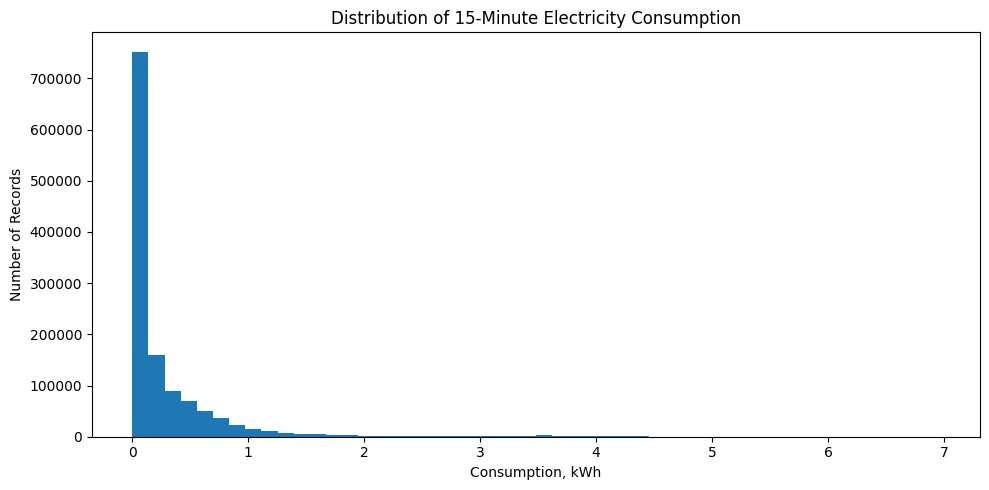

In [25]:
# Plot the distribution of 15-minute electricity consumption values

plt.figure(figsize=(10, 5))
plt.hist(consumption["consumption_kwh"], bins=50)

plt.title("Distribution of 15-Minute Electricity Consumption")
plt.xlabel("Consumption, kWh")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

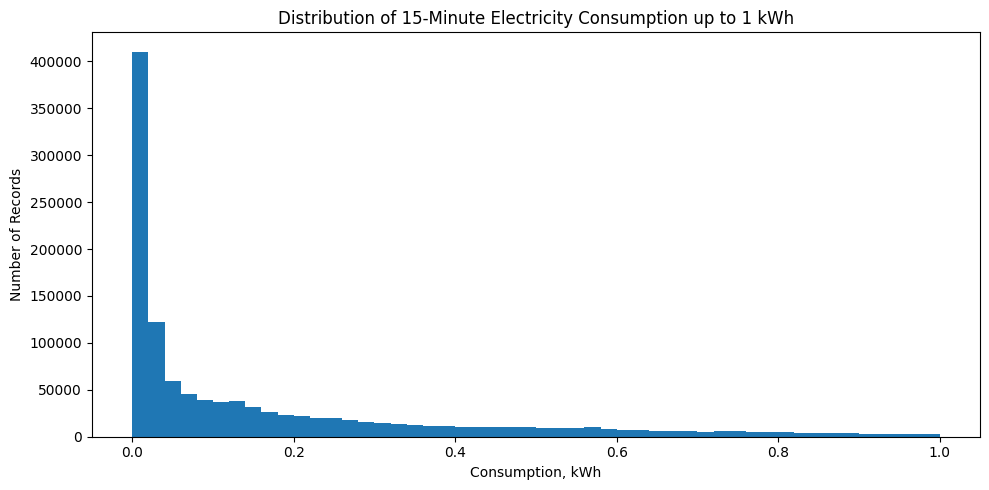

In [26]:
# Plot the distribution without very high peak values

plt.figure(figsize=(10, 5))
plt.hist(
    consumption[consumption["consumption_kwh"] <= 1]["consumption_kwh"],
    bins=50
)

plt.title("Distribution of 15-Minute Electricity Consumption up to 1 kWh")
plt.xlabel("Consumption, kWh")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()